In [1]:
import numpy as np
import pandas as pd
df=pd.read_csv('disease_prediction_dataset.csv')
df

,Age,BMI,Blood_Pressure,Glucose_Level,Cholesterol,Heart_Rate,Smoking,Alcohol,Physical_Activity,Family_History,Disease
0,56,20.7,154,117,249,87,1,0,4.9,0,1
1,69,33.3,176,142,316,72,0,0,1.7,0,1
2,46,30.7,97,141,245,103,0,0,2.7,0,1
3,32,24.1,166,185,197,95,0,0,3.1,0,0
4,60,19.1,161,242,178,63,0,0,6.2,0,1
...,...,...,...,...,...,...,...,...,...,...,...
995,78,32.2,140,101,276,74,0,0,5.7,1,1
996,23,26.1,136,124,199,81,0,1,6.7,0,0
997,35,23.0,93,165,215,60,0,0,6.2,1,0
998,68,27.8,96,202,226,81,0,0,6.5,0,0


In [2]:
df.shape

(1000, 11)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                1000 non-null   int64  
 1   BMI                1000 non-null   float64
 2   Blood_Pressure     1000 non-null   int64  
 3   Glucose_Level      1000 non-null   int64  
 4   Cholesterol        1000 non-null   int64  
 5   Heart_Rate         1000 non-null   int64  
 6   Smoking            1000 non-null   int64  
 7   Alcohol            1000 non-null   int64  
 8   Physical_Activity  1000 non-null   float64
 9   Family_History     1000 non-null   int64  
 10  Disease            1000 non-null   int64  
dtypes: float64(2), int64(9)
memory usage: 86.1 KB


In [4]:
df.describe()

,Age,BMI,Blood_Pressure,Glucose_Level,Cholesterol,Heart_Rate,Smoking,Alcohol,Physical_Activity,Family_History,Disease
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,50.380000,26.164800,133.942000,159.470000,234.043000,83.030000,0.302000,0.346000,3.515900,0.263000,0.678000
std,18.378666,3.991036,26.058851,51.485453,52.001609,15.985325,0.459355,0.475931,2.010482,0.440483,0.467477
min,18.000000,16.000000,90.000000,70.000000,140.000000,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,23.500000,111.000000,117.000000,191.000000,70.000000,0.000000,0.000000,1.800000,0.000000,0.000000
50%,50.000000,26.100000,134.000000,158.000000,237.000000,82.000000,0.000000,0.000000,3.600000,0.000000,1.000000
75%,66.000000,28.700000,156.000000,204.000000,279.000000,97.000000,1.000000,1.000000,5.300000,1.000000,1.000000
max,80.000000,38.300000,180.000000,250.000000,320.000000,110.000000,1.000000,1.000000,7.000000,1.000000,1.000000


## Feature and target Extraction

In [5]:
X=df.drop(['Disease'],axis=1)
y=df['Disease']

## Train Test Spilt

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42)

In [7]:
X_train.head()

,Age,BMI,Blood_Pressure,Glucose_Level,Cholesterol,Heart_Rate,Smoking,Alcohol,Physical_Activity,Family_History
29,38,33.0,99,238,185,79,0,0,4.4,0
535,75,27.5,152,201,245,93,0,0,5.1,0
695,72,27.0,97,96,288,72,1,0,1.2,0
557,68,27.0,180,96,280,58,0,0,0.9,0
836,40,29.9,117,227,215,71,1,1,1.7,0


In [8]:
X_train.shape

(800, 10)

# Feature Scaling

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
X_train

array([[-0.6786081 ,  1.71510338, -1.32734664, ..., -0.73379939,
         0.44674503, -0.60430763],
       [ 1.34240003,  0.33360134,  0.68242008, ..., -0.73379939,
         0.79382774, -0.60430763],
       [ 1.17853451,  0.20801025, -1.40318689, ..., -0.73379939,
        -1.13991878, -0.60430763],
       ...,
       [-1.55255757, -2.05262945, -0.94814537, ..., -0.73379939,
        -1.68533447,  1.65478632],
       [ 0.79618162, -0.57065453,  0.94786097, ...,  1.36277029,
        -0.39617012, -0.60430763],
       [-1.27944836,  1.48903941,  1.28914211, ...,  1.36277029,
        -0.04908741,  1.65478632]], shape=(800, 10))

In [11]:
#import KNN
from sklearn.neighbors import KNeighborsClassifier


In [12]:
knn=KNeighborsClassifier(n_neighbors=5)

In [13]:
knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

scores = []

for i in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    scores.append(accuracy_score(y_test, y_pred))
scores

[0.83, 0.805, 0.87, 0.86, 0.895, 0.9, 0.89, 0.885, 0.885, 0.885]

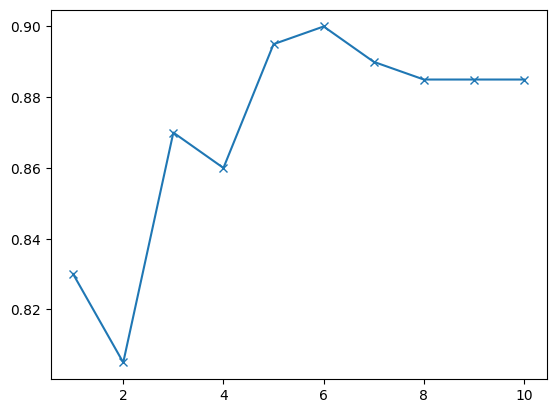

In [15]:
import matplotlib.pyplot as plt
plt.plot(range(1,11),scores,marker='x')
plt.show()